In [43]:
import DataMaker
import DataHolder
import buildmodel

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import time

In [44]:
ntrain = 25
nval = 13
test = np.arange(38,50)

trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

In [45]:
# ssplist = ["245"]#,"370","585"]

# set user parameters

latsel = 40
lonsel = 250
ssp = "245" 

historical_era = [1960,2000]
tpercentile = 95
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 3

# data params
outres = 10
timerange = [1950,2080]
filefront = "MPI_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

In [46]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "ssp": ssp,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
}

ntrain = 25
nval = 13
test = np.arange(38,50)

#get the data

AllData = DataHolder.MPIInputOutput(params)


data/MPI_annualmean_245_tos.pkl


In [47]:
import glob
glob.glob("models/"+filefront+"avgtime"+str(outputavgtime)+"_ssp"+ssp+"_per"+str(tpercentile)+"_lat"+str(latsel)+"_lon"+str(lonsel)+"_*.pt")

['models/MPI_avgtime3_ssp245_per95_lat40_lon250_seed18469465.pt']

Seed  18469465  val accuracy:  0.8616677440206852
GMT only val accuracy:  0.8778280542986425


(2000.0, 2040.0)

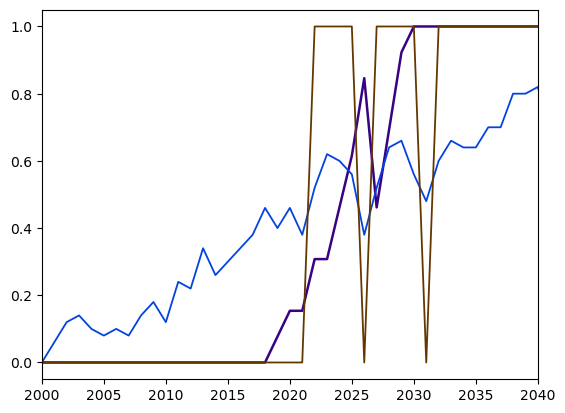

In [51]:
plt.subplot(1,1,1)
allpred = []

for iseed, seed in enumerate(seedlist[6:7]):

    torch.manual_seed(seed) 
    np.random.seed(seed)

    trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

    trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

    alltrain, allval, alltest = AllData.trainvaltest_binaryclassifier(trainvaltest, historical_era,inputlength,outputavgtime, tpercentile, latsel, lonsel)

    inputtrain, inputtrainGMT, outputtrain = DataHolder.tensortime_onehot(alltrain,nclasses=2)
    inputval, inputvalGMT, outputval = DataHolder.tensortime_onehot(allval,nclasses=2)
    inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)
    
    outputvalclass = np.argmax(outputval.numpy(),axis=1)

    #baseline of beating gmt, need to get gmt

    gmtallmembers = AllData.alloutput
    avgeffectofGMT_train = np.mean(gmtallmembers[:], axis=0)
    avgeffectofGMTabs = np.round(avgeffectofGMT_train, decimals=0)
    avgeffectofGMTval = np.tile(avgeffectofGMTabs, (len(trainvaltest[1])))

    avgeffectofGMT_test = np.mean(gmtallmembers[:], axis=0)

    yearvec = np.arange(timerange[0]+inputlength, timerange[1]-outputavgtime+2)
    gmtplot = np.reshape(inputtrainGMT.numpy().squeeze(),(len(trainvaltest[0]),len(yearvec)))
    gmtplot = np.mean(gmtplot,axis=0)

    cnn = buildmodel.CNNclassifier(inputtrain, inputtrainGMT, outputtrain)
    fileout = "models/"+filefront+"avgtime"+str(outputavgtime)+"_ssp"+ssp+"_per"+str(tpercentile)+"_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed"+str(seed)+".pt"
    cnn.load_state_dict(torch.load(fileout, weights_only=True,map_location=torch.device('cpu')) )
    cnn.eval()

    with torch.no_grad():
        predval = cnn(inputval, inputvalGMT)

    predvalclass = torch.argmax(predval, dim=1).numpy()
    allpred.append(predval.numpy())
    acc = np.mean(predvalclass == outputvalclass)
    print("Seed ", str(seed), " val accuracy: ", str(acc))


    predseed = allpred[iseed]
    predseed = np.argmax(predseed, axis=1)
    predseed = np.reshape(predseed, (len(trainvaltest[1]), len(yearvec)))

    predseedmean = np.mean(predseed, axis=0)
    plt.plot(yearvec,predseedmean,label='Seed '+str(seed),linewidth=1.8,color='xkcd:indigo')

    # for i in range(len(trainvaltest[2])):
    #     plt.scatter(yearvec, allpred[iseed][i*len(yearvec):(i+1)*len(yearvec),1], color='xkcd:light purple', s=8)

    #     plt.title('ssp '+ssp + ' tpercentile' + str(tpercentile))

plt.plot(yearvec,avgeffectofGMT_test,color='xkcd:blue',label='GMT only',linewidth=1.3)
plt.plot(yearvec,avgeffectofGMTabs,color='xkcd:brown',label='GMT only',linewidth=1.3)

gmtonlyacc = np.mean(avgeffectofGMTval == outputvalclass)
print("GMT only val accuracy: ", str(gmtonlyacc))

plt.xlim(2000,2040)


In [33]:
gmtonlyacc = np.mean(avgeffectofGMTval == outputvalclass)
print("GMT only val accuracy: ", str(gmtonlyacc))


GMT only val accuracy:  0.8797672915319974


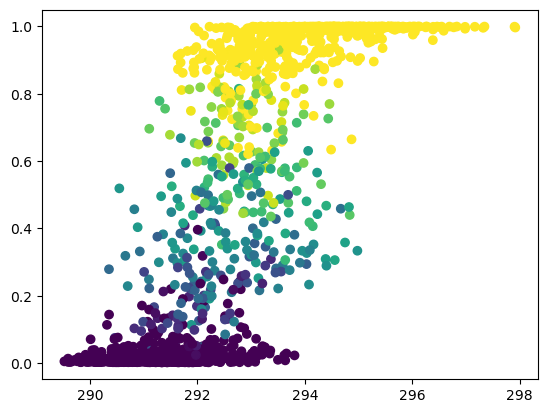

In [34]:
plt.scatter(AllData.truesummer[25:38].flatten(),allpred[0][:,1],c=inputvalGMT.numpy(),vmin=0.3,vmax=0.8)

In [35]:
AllData.input_annualmean.shape

(50, 131, 45, 90)

In [36]:
imp.reload(DataHolder)

plotnum = 0

outputavgtime = 3

plt.figure(figsize=(12,8))

for ssp in ssplist:
    for tpercentile in [90]:

        params = {
            "inputlength": inputlength,
            "outputavgtime": outputavgtime,
            "outres": outres,
            "ssp": ssp,
            "timerange": timerange,
            "filefront": filefront,
            "inres": inres,
            "inputvar":inputvar,
            "outputvar":outputvar,
            "seedlist": seedlist,
        }

        #get the data

        AllData = DataHolder.MPIInputOutput(params)

        alltrain, allval, alltest = AllData.trainvaltest_binaryclassifier(trainvaltest, historical_era, inputlength, outputavgtime,  tpercentile, latsel, lonsel)

        inputtrain, inputtrainGMT, outputtrain = DataHolder.tensortime_onehot(alltrain,nclasses=2)
        inputval, inputvalGMT, outputval = DataHolder.tensortime_onehot(allval,nclasses=2)
        inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)

        
        outputval = torch.argmax(outputval, dim=1).numpy()

        #baseline of beating gmt, need to get gmt

        gmtallmembers = AllData.alloutput
        avgeffectofGMT = np.mean(gmtallmembers[:25], axis=0)
        avgeffectofGMTabs = np.round(avgeffectofGMT, decimals=0)
        avgeffectofGMTval = np.tile(avgeffectofGMTabs, (len(trainvaltest[1])))

        allpred = []

        for iseed, seed in enumerate(seedlist):

            cnn = buildmodel.CNNclassifier(inputtrain, inputtrainGMT, outputtrain)
            fileout = "models/"+filefront+"ssp"+ssp+"_per"+str(tpercentile)+"_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed"+str(seed)+".pt"
            cnn.load_state_dict(torch.load(fileout, weights_only=True))
            cnn.eval()

            with torch.no_grad():
                predval = cnn(inputval, inputvalGMT)

            predvalclass = torch.argmax(predval, dim=1).numpy()
            allpred.append(predval.numpy())
            acc = np.mean(predvalclass == outputval)
            print("Seed ", str(seed), " val accuracy: ", str(acc))

        gmtonlyacc = np.mean(avgeffectofGMTval == outputval)
        print("GMT only val accuracy: ", str(gmtonlyacc))


        yearvec = np.arange(timerange[0]+inputlength, timerange[1]-outputavgtime+2)

        gmtplot = np.reshape(inputtrainGMT.numpy().squeeze(),(len(trainvaltest[0]),len(yearvec)))
        gmtplot = np.mean(gmtplot,axis=0)


        plt.subplot(2,1,plotnum+1)
        plt.plot(yearvec,avgeffectofGMT,color='xkcd:blue',label='GMT only',linewidth=1.3)
        # plt.plot(yearvec,avgeffectofGMTabs,color='xkcd:brown',label='GMT only',linewidth=1.3)
        # plt.plot(yearvec,gmtplot)

        for iseed, seed in enumerate(seedlist):
            predseed = allpred[iseed]
            predseed = np.argmax(predseed, axis=1)
            predseed = np.reshape(predseed, (len(trainvaltest[1]), len(yearvec)))

            predseedmean = np.mean(predseed, axis=0)
            plt.plot(yearvec,predseedmean,label='Seed '+str(seed),linewidth=1.8,color='xkcd:indigo')

            for i in range(len(trainvaltest[2])):
                plt.scatter(yearvec, allpred[iseed][i*len(yearvec):(i+1)*len(yearvec),1], color='xkcd:light purple', s=8)

        plt.title('ssp '+ssp + ' tpercentile' + str(tpercentile))

        plotnum+=1 
plt.tight_layout()
plt.show()


NameError: name 'ssplist' is not defined

<Figure size 1200x800 with 0 Axes>

In [ ]:
timerange

[1950, 2080]

In [ ]:
filefront

'MPI_'

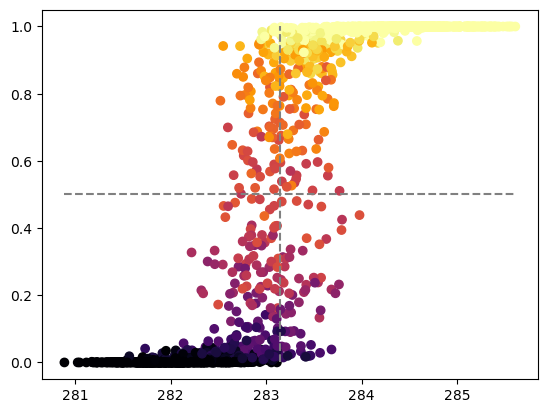

In [ ]:
plt.scatter(AllData.truesummer[25:38].flatten(),allpred[1][:,1],c=inputvalGMT.numpy(),cmap='inferno',vmin=0,vmax=0.8)
avgextreme = np.mean(AllData.onesigmas,axis=0)
plt.vlines(avgextreme,0,1,color='grey',linestyle='--')
plt.hlines(0.5,np.min(AllData.truesummer[25:38]),np.max(AllData.truesummer[25:38]),color='grey',linestyle='--')

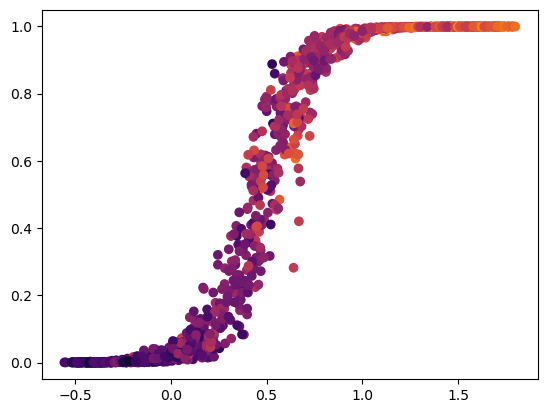

In [ ]:
plt.scatter(inputvalGMT.numpy(),allpred[1][:,1],c=AllData.truesummer[25:38].flatten(),cmap='inferno')

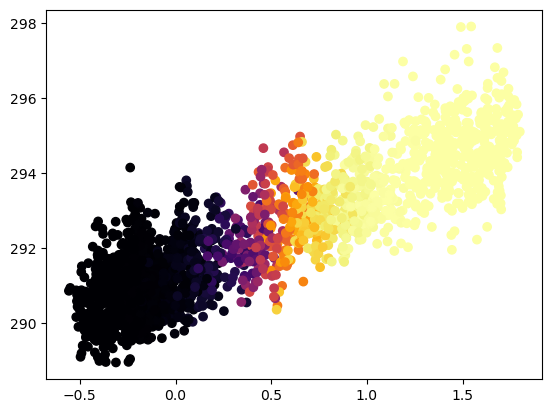

In [ ]:
plt.scatter(inputvalGMT.numpy(),AllData.truesummer[25:38].flatten(),c=allpred[1][:,1],cmap='inferno')

In [ ]:
a = np.arange(7340)

np.percentile(a,100)

7339.0